In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from io import StringIO  # To load CSV from string

In [2]:
df = pd.read_csv("processed_feature_selected.csv")

In [3]:
min_class_size = df['fat_level'].value_counts().min()
df_balanced = df.groupby('fat_level').sample(min_class_size, random_state=42)
print("Balanced Dataset Shape:", df_balanced.shape)

Balanced Dataset Shape: (9072, 11)


            rating          fat     calories      protein       sodium  \
count  9072.000000  9072.000000  9072.000000  9072.000000  9072.000000   
mean      0.554270     0.251643     0.294593     0.196837     0.221928   
std       0.275436     0.205483     0.182129     0.212441     0.224525   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.333333     0.108108     0.163197     0.044118     0.046118   
50%       0.666667     0.202703     0.252290     0.102941     0.143024   
75%       0.666667     0.337838     0.398834     0.279412     0.335668   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

        high fiber  fat_level_medium  fat_level_high  health_score  
count  9072.000000       9072.000000     9072.000000   9072.000000  
mean      0.046186          0.333333        0.333333      0.528909  
std       0.209899          0.471431        0.471431      0.156674  
min       0.000000          0.000000        0.000000     

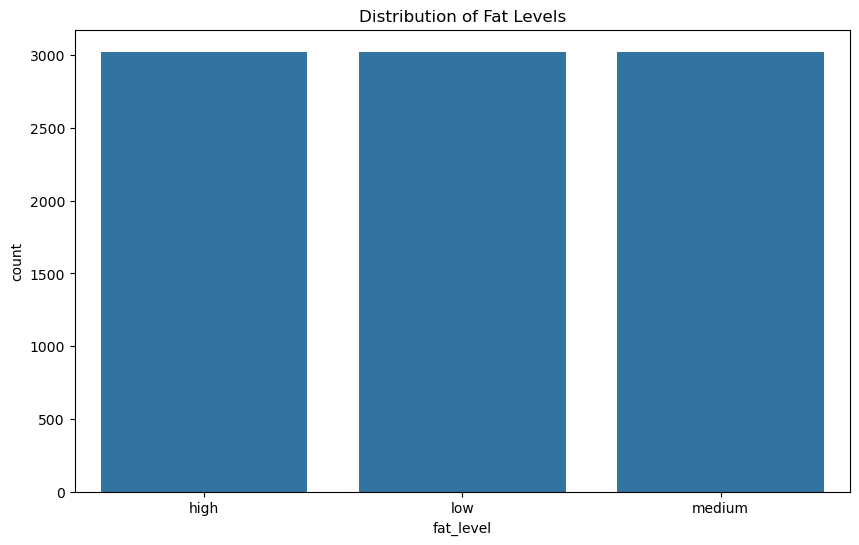

In [5]:
# STEP 2: Exploratory Data Analysis
# Basic stats
print(df_balanced.describe())

# Visualize distributions
plt.figure(figsize=(10, 6))
sns.countplot(x='fat_level', data=df_balanced)
plt.title('Distribution of Fat Levels')
plt.show()

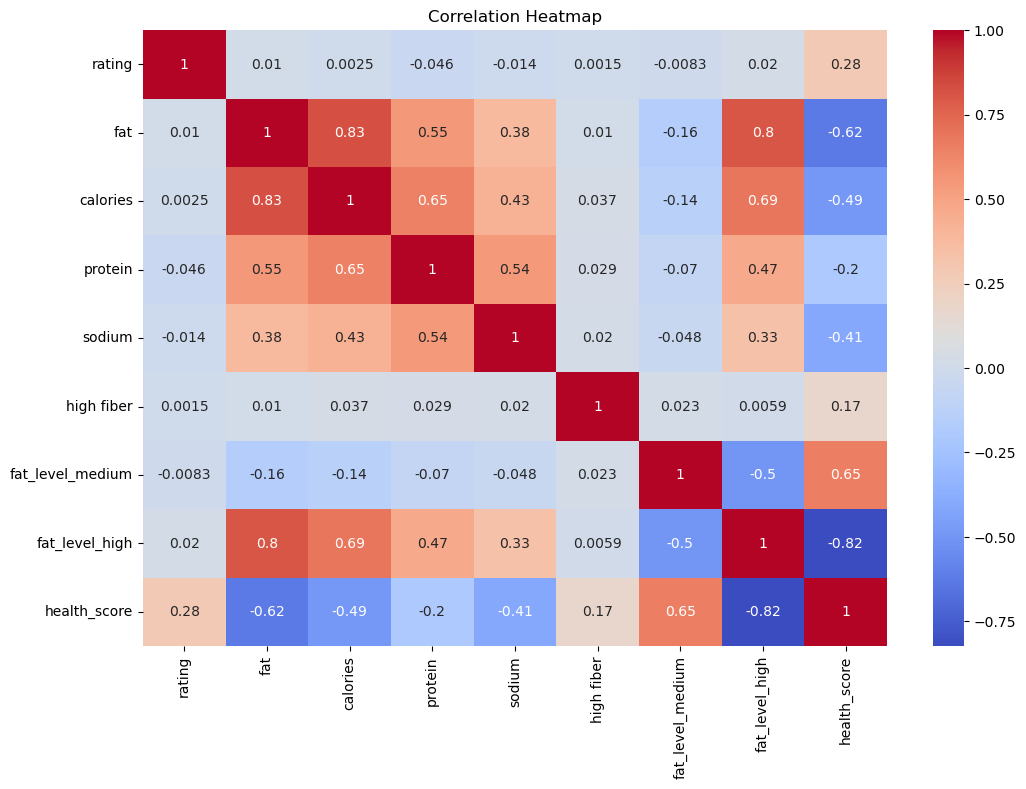

In [6]:
# Correlation heatmap (numeric features only)
numeric_df = df_balanced.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [9]:
# STEP 3: Feature Preprocessing
# Drop 'title' as it's text, and 'health_score' if not using (assuming it's derived)
# Also drop dummy columns if using 'fat_level' as target
features = ['rating', 'fat', 'calories', 'protein', 'sodium', 'high fiber']
X = df_balanced[features]
y = df_balanced['fat_level']

# Encode target if categorical (low, medium, high)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# Check the target variables
print("Unique Target Classes:", le.classes_)
print("Target Distribution in Train:", np.unique(y_train, return_counts=True))

Unique Target Classes: ['high' 'low' 'medium']
Target Distribution in Train: (array([0, 1, 2]), array([2415, 2420, 2422]))


Accuracy: 0.9228650137741047
Classification Report:
               precision    recall  f1-score   support

        high       0.95      0.92      0.94       609
         low       0.96      0.94      0.95       604
      medium       0.87      0.91      0.89       602

    accuracy                           0.92      1815
   macro avg       0.92      0.92      0.92      1815
weighted avg       0.92      0.92      0.92      1815

Confusion Matrix:
 [[563   1  45]
 [  0 565  39]
 [ 32  23 547]]


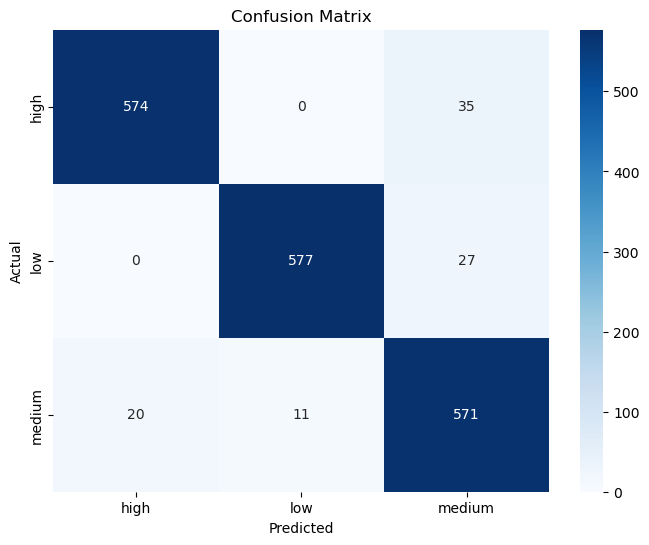

In [17]:
# STEP 4: Model Training and Evaluation
# Basic KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # Default k=5
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Visualize the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred_tuned are available from the previous code
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [15]:
# STEP 5: Advanced Hyperparameter Tuning for KNN Model
# Grid search for best k, weights, etc.
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_knn = grid_search.best_estimator_

# Evaluate tuned model
y_pred_tuned = best_knn.predict(X_test)
print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Tuned Accuracy: 0.9487603305785124


In [12]:
# STEP 6: Cross-Validation Analysis
# Cross-validation on tuned model
cv_scores = cross_val_score(best_knn, X_scaled, y_encoded, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.94545455 0.95041322 0.94873208 0.94707828 0.94818082]
Mean CV Accuracy: 0.9479717896616764


In [13]:
# STEP 7: Model Comparison and Final Evaluation
# For comparison, you could add another model like Decision Tree, but since focus is KNN, we'll just finalize.
# Final evaluation on test set (already done above)
print("Final Tuned KNN Model Evaluation:")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

Final Tuned KNN Model Evaluation:
              precision    recall  f1-score   support

        high       0.97      0.94      0.95       609
         low       0.98      0.96      0.97       604
      medium       0.90      0.95      0.92       602

    accuracy                           0.95      1815
   macro avg       0.95      0.95      0.95      1815
weighted avg       0.95      0.95      0.95      1815

